# Monthly Wind‑Rose Analysis for Prampram in 2024 using NASA POWER 2m Wind Speed and Direction Data

## Name: Prince Kwesi Lassey
## Index: 35...
## Reference: 20...

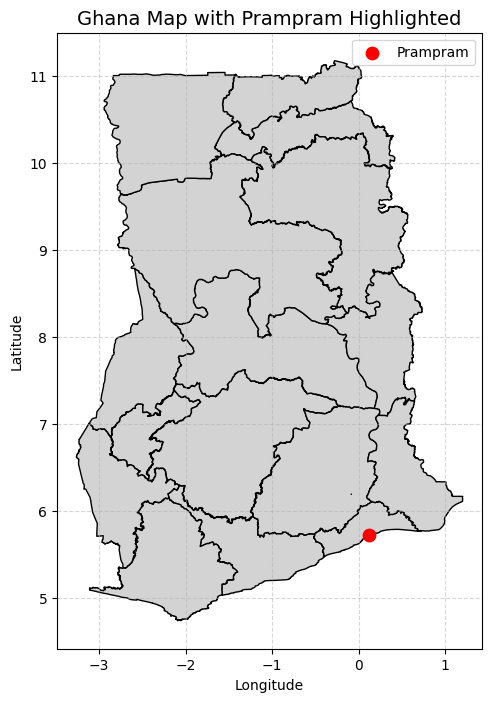

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

#load shapefile
ghana = gpd.read_file("gadm41_GHA_1.shp")

# plot the figure
fig, ax = plt.subplots(figsize=(8, 8))
ghana.plot(ax=ax, color="lightgrey", edgecolor="black")

# prampram coordinates
prampram_lat = 5.7256527566940925
prampram_lon = 0.11584993828518059

prampram = gpd.GeoDataFrame(
    {"name": ["Prampram"]},
    geometry=gpd.points_from_xy([prampram_lon], [prampram_lat]),
    crs="EPSG:4326"
)


# point with label for legend
prampram.plot(ax=ax, color="red", markersize=80, label="Prampram")


ax.set_title("Ghana Map with Prampram Highlighted", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)

ax.legend()

plt.show()

In [1]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for plotting
import xarray as xr # to load the netcdf file as I try to use that as well
from windrose import WindroseAxes # for creating wind rose plots
import calendar # added this to get the month names instead of expressing them as numbers

## Using Netcdf Data

In [2]:
# loaded and combined both datasets by coordinates
wind = xr.open_mfdataset("*.nc", combine="by_coords")

In [3]:
# expanded to  take a look at the resulting dataset
wind

<xarray.Dataset> Size: 706kB
Dimensions:  (time: 366, lat: 15, lon: 8)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 120B 4.5 5.0 5.5 6.0 6.5 ... 9.5 10.0 10.5 11.0 11.5
  * lon      (lon) float64 64B -3.125 -2.5 -1.875 -1.25 ... -5.92e-13 0.625 1.25
Data variables:
    WD2M     (time, lat, lon) float64 351kB dask.array<chunksize=(366, 15, 8), meta=np.ndarray>
    WS2M     (time, lat, lon) float64 351kB dask.array<chunksize=(366, 15, 8), meta=np.ndarray>
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Energy Resource (POWER)
    standard_name_vocabulary:  CF Standard Name Table v72
    summary:                   The POWER project provides solar and meteorolo...
    version:                   POWER Version 10.0.0

In [7]:
# defined the coordinaates for prampram as seen on googole maps
prampram_lat = 5.7256527566940925
prampram_lon = 0.11584993828518059

# then the nearest gridpoint to pramppram in the dataset is selected
wind_point = wind.sel(lat=prampram_lat, lon=prampram_lon, method="nearest")

# taking the value of the nearest coordinates that would be used for the plot
# this coordinates would be displayed on the plot itself
nearest_lat = float(wind_point["lat"].values)
nearest_lon = float(wind_point["lon"].values)

In [8]:
# before plotting, the data has to be converted into dataframe
# showed errors when I tried to just go ahead with plotting
dataframe = pd.DataFrame({
    "date": wind_point["time"].values,
    "WS2M": wind_point["WS2M"].values,
    "WD2M": wind_point["WD2M"].values
    })

dataframe["date"] = pd.to_datetime(dataframe["date"])
dataframe["month"] = dataframe["date"].dt.month

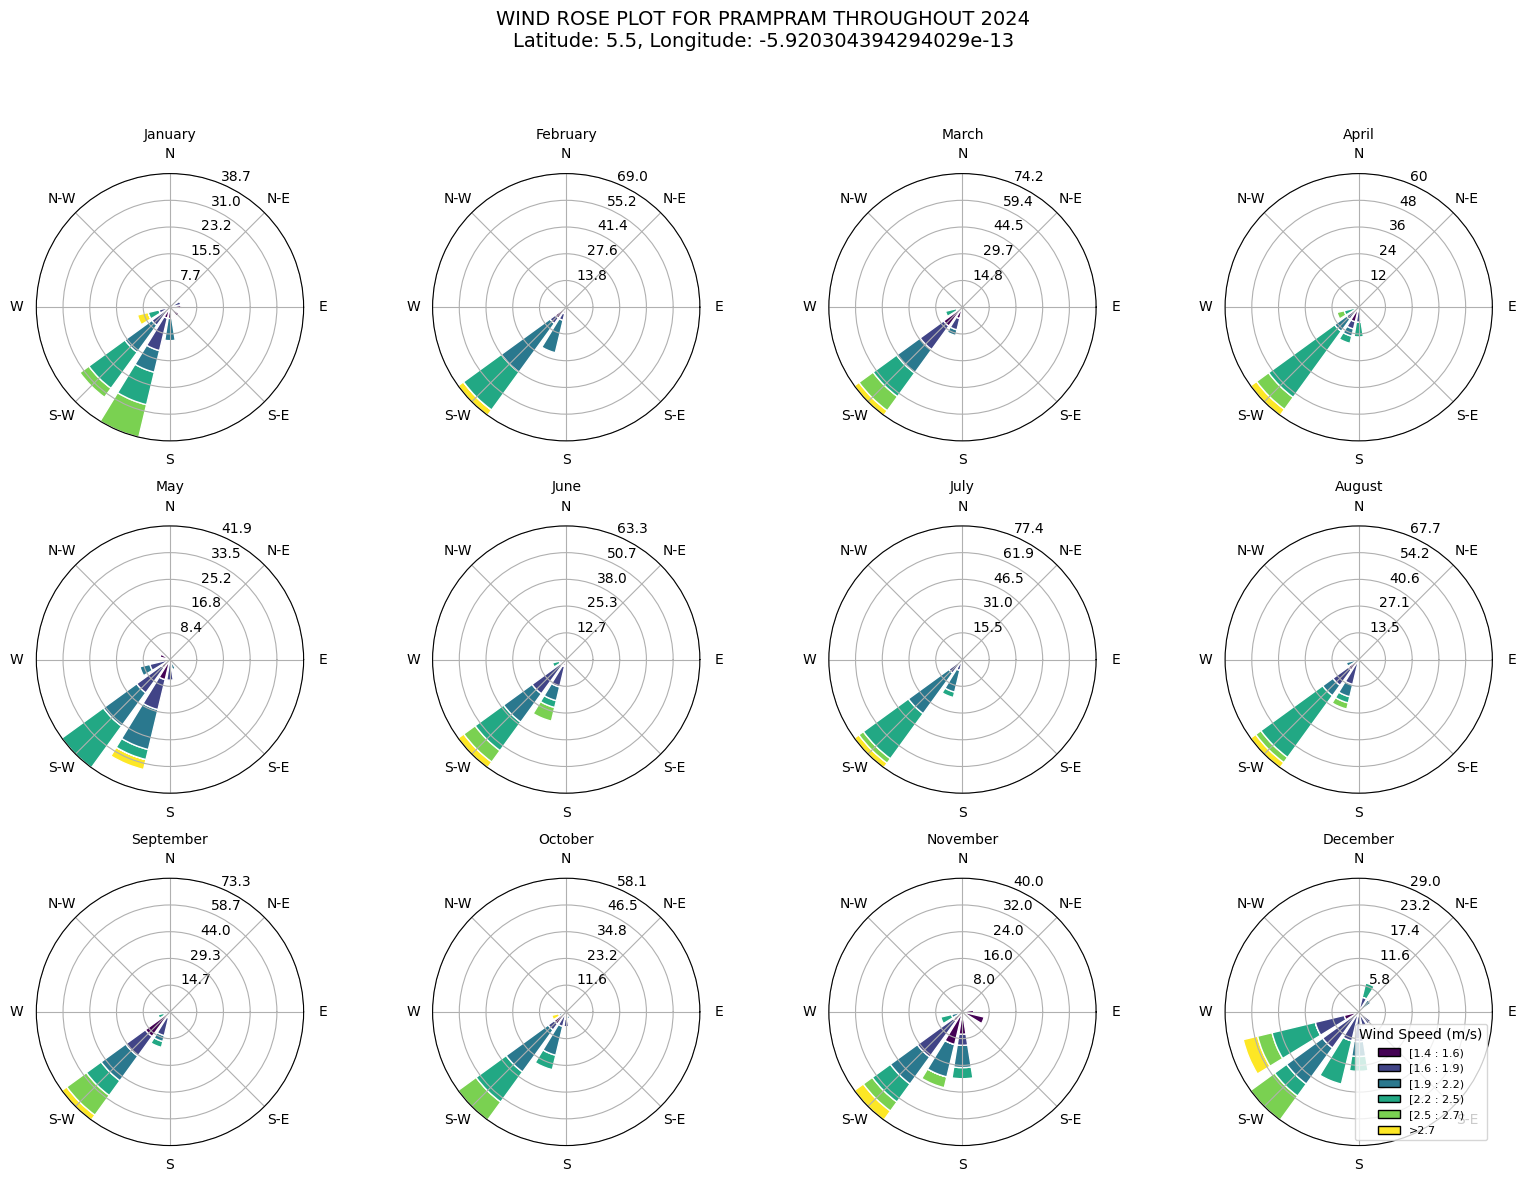

In [10]:
# created the figure.. just as was done for the figure when I used the csv
fig, axes = plt.subplots(3, 4,figsize=(16, 12),subplot_kw={"projection": "windrose"})

for m, ax in enumerate(axes.flatten(), start=1):
    d = dataframe[dataframe["month"] == m]

    ax.bar(d["WD2M"],d["WS2M"],normed=True,opening=0.8,edgecolor="white")
    ax.set_title(calendar.month_name[m], fontsize=10)

fig.suptitle(f"WIND ROSE PLOT FOR PRAMPRAM THROUGHOUT 2024\nLatitude: {nearest_lat}, Longitude: {nearest_lon}",fontsize=14)

# single legend on last subplot
axes.flatten()[-1].legend(title='Wind Speed (m/s)',loc="lower right", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()